In [25]:
import os
from pathlib import Path

from dotenv import load_dotenv

from langchain_community.document_loaders import PyPDFLoader

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_huggingface import HuggingFaceEmbeddings

from langchain_chroma import Chroma

from langgraph.graph import StateGraph, START, END

In [26]:
load_dotenv()

print("Environment loaded successfully.")

Environment loaded successfully.


In [27]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PDF_DIR = DATA_DIR / "pdf"

PDF_PATH = PDF_DIR / "resume.pdf"

print("Project root:", PROJECT_ROOT)
print("PDF path:", PDF_PATH)
print("PDF exists:", PDF_PATH.exists())

Project root: c:\projects\RAG
PDF path: c:\projects\RAG\data\pdf\resume.pdf
PDF exists: True


In [28]:
loader = PyPDFLoader(str(PDF_PATH))

documents = loader.load()

print(f"Number of pages loaded: {len(documents)}")

Number of pages loaded: 1


In [29]:
print(type(documents[0]))

<class 'langchain_core.documents.base.Document'>


In [30]:
print(documents[0])

page_content='Smruti Ranjan Kodamasingh♂phone+91-9178763926
Software engineer✉smrutiranjankodamasingh19@gmail.com
Bachelor of Technology /githubGitHub Profile
Kalinga Institute of Industrial Technology, Bhubaneswar/linkedinLinkedIn Profile
Educa tion
•Bachelor of Technology in Computer Science and Engineering2021-25
Kalinga Institute of Industrial Technology, BhubaneswarCGPA: 8.4
Personal Projects
•Deep Packet Inspection
C++, FastAPI, React, Docker, GitHub ActionsLive link | GitHub
–Built a multithreaded packet-inspection engine in C++17 from raw sockets up, writing custom byte-level parsers
for Ethernet, IPv4, TCP/UDP, and TLS ClientHello (SNI extraction) with zero external networking libraries.
–Architected a load-balancer→fast-path thread-pool pipeline using consistent hashing on the 5-tuple (src/dst IP,
port, protocol), guaranteeing every packet in a connection is processed by the same worker thread and preserving
flow-state correctness under concurrency.
–Implemented a lock-based 

In [31]:
print("CONTENT")
print(documents[0].page_content)

print("\nMETADATA")
print(documents[0].metadata)

CONTENT
Smruti Ranjan Kodamasingh♂phone+91-9178763926
Software engineer✉smrutiranjankodamasingh19@gmail.com
Bachelor of Technology /githubGitHub Profile
Kalinga Institute of Industrial Technology, Bhubaneswar/linkedinLinkedIn Profile
Educa tion
•Bachelor of Technology in Computer Science and Engineering2021-25
Kalinga Institute of Industrial Technology, BhubaneswarCGPA: 8.4
Personal Projects
•Deep Packet Inspection
C++, FastAPI, React, Docker, GitHub ActionsLive link | GitHub
–Built a multithreaded packet-inspection engine in C++17 from raw sockets up, writing custom byte-level parsers
for Ethernet, IPv4, TCP/UDP, and TLS ClientHello (SNI extraction) with zero external networking libraries.
–Architected a load-balancer→fast-path thread-pool pipeline using consistent hashing on the 5-tuple (src/dst IP,
port, protocol), guaranteeing every packet in a connection is processed by the same worker thread and preserving
flow-state correctness under concurrency.
–Implemented a lock-based produc

In [32]:
for i, doc in enumerate(documents):
    print(f"Page {i + 1}")
    print(f"Characters: {len(doc.page_content)}")
    print(f"Metadata: {doc.metadata}")
    print("-" * 80)

Page 1
Characters: 3352
Metadata: {'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-08-22T10:20:38+00:00', 'author': '', 'keywords': '', 'moddate': '2026-08-22T10:20:38+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) kpathsea version 6.4.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'c:\\projects\\RAG\\data\\pdf\\resume.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}
--------------------------------------------------------------------------------


#### Load the tokenizer

In [33]:
from transformers import AutoTokenizer

EMBEDDING_MODEL = "BAAI/bge-m3"

tokenizer = AutoTokenizer.from_pretrained(
    EMBEDDING_MODEL
)

print("Tokenizer loaded:", EMBEDDING_MODEL)

Tokenizer loaded: BAAI/bge-m3


#### Create the text splitter

In [34]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer=tokenizer,
    chunk_size=700,
    chunk_overlap=100,
    separators=[
        "\n\n",
        "\n",
        " ",
        ""
    ]
)

chunks = text_splitter.split_documents(documents)

print(f"Original documents : {len(documents)}")
print(f"Generated chunks   : {len(chunks)}")

Original documents : 1
Generated chunks   : 2


#### Verify the actual token counts

In [35]:
for i, chunk in enumerate(chunks):
    token_count = len(
        tokenizer.encode(
            chunk.page_content,
            add_special_tokens=False
        )
    )

    print(
        f"Chunk {i}: "
        f"{token_count} tokens | "
        f"{len(chunk.page_content)} characters"
    )

Chunk 0: 690 tokens | 2623 characters
Chunk 1: 283 tokens | 1091 characters


#### Create the embeddings

In [36]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={
        "device": "cpu"
    },
    encode_kwargs={
        "normalize_embeddings": True
    }
)

print("Embedding model loaded.")

Error in sys.excepthook:
Traceback (most recent call last):
  File "c:\Users\smrut\miniconda3\envs\rag\Lib\site-packages\ipykernel\iostream.py", line 217, in _event_pipe
    event_pipe = self._local.event_pipe
                 ^^^^^^^^^^^^^^^^^^^^^^
AttributeError: '_thread._local' object has no attribute 'event_pipe'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\smrut\miniconda3\envs\rag\Lib\site-packages\IPython\core\interactiveshell.py", line 2124, in excepthook
    self.showtraceback((etype, value, tb), tb_offset=0)
    ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\smrut\miniconda3\envs\rag\Lib\site-packages\IPython\core\interactiveshell.py", line 2246, in showtraceback
    self._showtraceback(etype, value, stb)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^
  File "c:\Users\smrut\miniconda3\envs\rag\Lib\site-packages\ipykernel\zmqshell.py", line 669, in _showtraceback
    sys.stdout.flus

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Embedding model loaded.


In [37]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

print("LLM initialized successfully.")

LLM initialized successfully.


#### Load the embedding model

In [38]:
from langchain_huggingface import HuggingFaceEmbeddings

EMBEDDING_MODEL = "BAAI/bge-m3"

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={
        "device": "cpu"
    },
    encode_kwargs={
        "normalize_embeddings": True
    }
)

print(f"Embedding model loaded: {EMBEDDING_MODEL}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Embedding model loaded: BAAI/bge-m3


#### Test one chunk

In [39]:
test_embedding = embeddings.embed_query(
    chunks[0].page_content
)

print("Embedding type:", type(test_embedding))
print("Embedding dimensions:", len(test_embedding))

Embedding type: <class 'list'>
Embedding dimensions: 1024


#### Inspect the embedding

In [40]:
print("First 10 values:")
print(test_embedding[:10])

First 10 values:
[-0.07484354078769684, -0.015085801482200623, -0.016723474487662315, -0.022889964282512665, -0.03267030045390129, -0.02554151602089405, -0.017832931131124496, -0.04074861481785774, 0.01268452126532793, 0.026701847091317177]


#### Embed all chunks

In [41]:
chunk_texts = [
    chunk.page_content
    for chunk in chunks
]

chunk_embeddings = embeddings.embed_documents(
    chunk_texts
)

print("Number of chunks:", len(chunk_embeddings))
print("Embedding dimensions:", len(chunk_embeddings[0]))

Number of chunks: 2
Embedding dimensions: 1024


#### Verify every chunk

In [42]:
for i, vector in enumerate(chunk_embeddings):
    print(
        f"Chunk {i}: "
        f"{len(vector)} dimensions"
    )

Chunk 0: 1024 dimensions
Chunk 1: 1024 dimensions


In [43]:
CHROMA_DIR = DATA_DIR / "chroma"

CHROMA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("ChromaDB directory:", CHROMA_DIR)

ChromaDB directory: c:\projects\RAG\data\chroma


In [44]:
for chunk in chunks:
    print(chunk.metadata.get("chunk_id"))

None
None


In [45]:
for i, chunk in enumerate(chunks):
    print(i, chunk.metadata)

0 {'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-08-22T10:20:38+00:00', 'author': '', 'keywords': '', 'moddate': '2026-08-22T10:20:38+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) kpathsea version 6.4.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'c:\\projects\\RAG\\data\\pdf\\resume.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}
1 {'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-08-22T10:20:38+00:00', 'author': '', 'keywords': '', 'moddate': '2026-08-22T10:20:38+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) kpathsea version 6.4.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'c:\\projects\\RAG\\data\\pdf\\resume.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}


In [46]:
for i, chunk in enumerate(chunks):
    chunk.metadata["chunk_id"] = (
        f"{Path(PDF_PATH).stem}"
        f"_page{chunk.metadata['page'] + 1}"
        f"_chunk{i}"
    )

In [47]:
for i, chunk in enumerate(chunks):
    print(
        i,
        "→",
        chunk.metadata.get("chunk_id")
    )

0 → resume_page1_chunk0
1 → resume_page1_chunk1


#### Create vectore store

In [49]:
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory=str(CHROMA_DIR),
    collection_name="rag_phase_1"
)

print("New collection created.")

New collection created.


#### Verify

In [50]:
stored_data = vectorstore._collection.get()

for metadata in stored_data["metadatas"]:
    print(
        "chunk_id:",
        metadata.get("chunk_id"),
        "| page:",
        metadata.get("page"),
        "| source:",
        metadata.get("source")
    )

chunk_id: resume_page1_chunk0 | page: 0 | source: c:\projects\RAG\data\pdf\resume.pdf
chunk_id: resume_page1_chunk1 | page: 0 | source: c:\projects\RAG\data\pdf\resume.pdf


In [51]:
print(
    "Documents stored:",
    vectorstore._collection.count()
)

Documents stored: 2


#### Test retrieval

In [52]:
query = "What projects has Smruti worked on?"

results = vectorstore.similarity_search(
    query,
    k=2
)

for i, doc in enumerate(results):
    print("=" * 100)
    print(f"RESULT {i + 1}")
    print("=" * 100)

    print("Chunk ID :", doc.metadata.get("chunk_id"))
    print("Page    :", doc.metadata.get("page"))
    print("Source  :", doc.metadata.get("source"))

    print("\nContent:")
    print(doc.page_content)
    print()

RESULT 1
Chunk ID : resume_page1_chunk0
Page    : 0
Source  : c:\projects\RAG\data\pdf\resume.pdf

Content:
Smruti Ranjan Kodamasingh♂phone+91-9178763926
Software engineer✉smrutiranjankodamasingh19@gmail.com
Bachelor of Technology /githubGitHub Profile
Kalinga Institute of Industrial Technology, Bhubaneswar/linkedinLinkedIn Profile
Educa tion
•Bachelor of Technology in Computer Science and Engineering2021-25
Kalinga Institute of Industrial Technology, BhubaneswarCGPA: 8.4
Personal Projects
•Deep Packet Inspection
C++, FastAPI, React, Docker, GitHub ActionsLive link | GitHub
–Built a multithreaded packet-inspection engine in C++17 from raw sockets up, writing custom byte-level parsers
for Ethernet, IPv4, TCP/UDP, and TLS ClientHello (SNI extraction) with zero external networking libraries.
–Architected a load-balancer→fast-path thread-pool pipeline using consistent hashing on the 5-tuple (src/dst IP,
port, protocol), guaranteeing every packet in a connection is processed by the same wor

In [53]:
query = "What programming languages does Smruti know?"

results = vectorstore.similarity_search(
    query,
    k=2
)

for i, doc in enumerate(results):
    print("=" * 100)
    print(f"RESULT {i + 1}")
    print("=" * 100)

    print("Chunk ID :", doc.metadata.get("chunk_id"))
    print("Page    :", doc.metadata.get("page"))
    print("Source  :", doc.metadata.get("source"))

    print("\nContent:")
    print(doc.page_content)
    print()

RESULT 1
Chunk ID : resume_page1_chunk0
Page    : 0
Source  : c:\projects\RAG\data\pdf\resume.pdf

Content:
Smruti Ranjan Kodamasingh♂phone+91-9178763926
Software engineer✉smrutiranjankodamasingh19@gmail.com
Bachelor of Technology /githubGitHub Profile
Kalinga Institute of Industrial Technology, Bhubaneswar/linkedinLinkedIn Profile
Educa tion
•Bachelor of Technology in Computer Science and Engineering2021-25
Kalinga Institute of Industrial Technology, BhubaneswarCGPA: 8.4
Personal Projects
•Deep Packet Inspection
C++, FastAPI, React, Docker, GitHub ActionsLive link | GitHub
–Built a multithreaded packet-inspection engine in C++17 from raw sockets up, writing custom byte-level parsers
for Ethernet, IPv4, TCP/UDP, and TLS ClientHello (SNI extraction) with zero external networking libraries.
–Architected a load-balancer→fast-path thread-pool pipeline using consistent hashing on the 5-tuple (src/dst IP,
port, protocol), guaranteeing every packet in a connection is processed by the same wor

In [54]:
query = "What programming languages does Smruti know?"

results = vectorstore.similarity_search_with_score(
    query,
    k=2
)

for i, (doc, score) in enumerate(results):
    print("=" * 100)
    print(f"RESULT {i + 1}")
    print("Score   :", score)
    print("Chunk ID:", doc.metadata.get("chunk_id"))
    print("=" * 100)

    print(doc.page_content[:800])
    print()

RESULT 1
Score   : 0.7494080066680908
Chunk ID: resume_page1_chunk0
Smruti Ranjan Kodamasingh♂phone+91-9178763926
Software engineer✉smrutiranjankodamasingh19@gmail.com
Bachelor of Technology /githubGitHub Profile
Kalinga Institute of Industrial Technology, Bhubaneswar/linkedinLinkedIn Profile
Educa tion
•Bachelor of Technology in Computer Science and Engineering2021-25
Kalinga Institute of Industrial Technology, BhubaneswarCGPA: 8.4
Personal Projects
•Deep Packet Inspection
C++, FastAPI, React, Docker, GitHub ActionsLive link | GitHub
–Built a multithreaded packet-inspection engine in C++17 from raw sockets up, writing custom byte-level parsers
for Ethernet, IPv4, TCP/UDP, and TLS ClientHello (SNI extraction) with zero external networking libraries.
–Architected a load-balancer→fast-path thread-pool pipeline using consistent hashing on the 5-tuple (src/dst

RESULT 2
Score   : 1.112017035484314
Chunk ID: resume_page1_chunk1
configurations.
–Automated budget variance commentary in Oracle

#### Create the retriever

In [55]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 2
    }
)

print("Retriever created successfully.")

Retriever created successfully.


#### Test the retriever

In [56]:
query = "What projects has Smruti worked on?"

retrieved_docs = retriever.invoke(query)

print(f"Retrieved documents: {len(retrieved_docs)}")

for i, doc in enumerate(retrieved_docs):
    print("=" * 100)
    print(f"RESULT {i + 1}")
    print("=" * 100)

    print("Chunk ID :", doc.metadata.get("chunk_id"))
    print("Page    :", doc.metadata.get("page"))
    print("Source  :", doc.metadata.get("source"))

    print("\nContent:")
    print(doc.page_content[:1000])

Retrieved documents: 2
RESULT 1
Chunk ID : resume_page1_chunk0
Page    : 0
Source  : c:\projects\RAG\data\pdf\resume.pdf

Content:
Smruti Ranjan Kodamasingh♂phone+91-9178763926
Software engineer✉smrutiranjankodamasingh19@gmail.com
Bachelor of Technology /githubGitHub Profile
Kalinga Institute of Industrial Technology, Bhubaneswar/linkedinLinkedIn Profile
Educa tion
•Bachelor of Technology in Computer Science and Engineering2021-25
Kalinga Institute of Industrial Technology, BhubaneswarCGPA: 8.4
Personal Projects
•Deep Packet Inspection
C++, FastAPI, React, Docker, GitHub ActionsLive link | GitHub
–Built a multithreaded packet-inspection engine in C++17 from raw sockets up, writing custom byte-level parsers
for Ethernet, IPv4, TCP/UDP, and TLS ClientHello (SNI extraction) with zero external networking libraries.
–Architected a load-balancer→fast-path thread-pool pipeline using consistent hashing on the 5-tuple (src/dst IP,
port, protocol), guaranteeing every packet in a connection is pr

#### Create a reusable retriever function

In [57]:
def retrieve_documents(query: str, k: int = 2):
    docs = vectorstore.similarity_search(
        query,
        k=k
    )

    return docs

In [58]:
docs = retrieve_documents(
    "What programming languages does Smruti know?"
)

for doc in docs:
    print(doc.metadata["chunk_id"])

resume_page1_chunk0
resume_page1_chunk1


#### Initialize Groq

In [59]:
from dotenv import load_dotenv
import os

load_dotenv()

print(
    "Groq API key exists:",
    bool(os.getenv("GROQ_API_KEY"))
)

Groq API key exists: True


#### Initialize the model

In [60]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

print("Groq LLM initialized successfully.")

Groq LLM initialized successfully.


#### Test the groq independently

In [61]:
response = llm.invoke(
    "Explain what a vector database is in one sentence."
)

print(response.content)

A vector database is a specialized data store that indexes and retrieves high‑dimensional vector embeddings (e.g., from text, images, or audio) to enable fast similarity search and nearest‑neighbor queries.


#### Create the RAG prompt

In [69]:
rag_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are a helpful question-answering assistant.

Answer the user's question using ONLY the information provided
in the retrieved context.

Rules:
- Do not use outside knowledge.
- If the answer cannot be found in the context, say:
  "I don't have enough information in the provided documents."
- Keep the answer concise and factual.
- Do not invent or assume information.
- When answering, cite the relevant source using the exact
  source identifier provided in the context.
- Format citations like: [Source: resume_page1_chunk0]

Retrieved context:
{context}
"""
    ),
    (
        "human",
        "{question}"
    )
])

#### Create a context formatter

In [70]:
def format_context(docs):
    formatted_chunks = []

    for doc in docs:
        chunk_id = doc.metadata.get("chunk_id", "unknown")
        source = doc.metadata.get("source", "unknown")
        page = doc.metadata.get("page", "unknown")

        formatted_chunks.append(
            f"[Source: {chunk_id} | Page: {page} | File: {source}]\n"
            f"{doc.page_content}"
        )

    return "\n\n".join(formatted_chunks)

#### Test the context Formatter

In [71]:
docs = retriever.invoke(
    "What projects has Smruti worked on?"
)

context = format_context(docs)

print(context)

[Source: resume_page1_chunk0 | Page: 0 | File: c:\projects\RAG\data\pdf\resume.pdf]
Smruti Ranjan Kodamasingh♂phone+91-9178763926
Software engineer✉smrutiranjankodamasingh19@gmail.com
Bachelor of Technology /githubGitHub Profile
Kalinga Institute of Industrial Technology, Bhubaneswar/linkedinLinkedIn Profile
Educa tion
•Bachelor of Technology in Computer Science and Engineering2021-25
Kalinga Institute of Industrial Technology, BhubaneswarCGPA: 8.4
Personal Projects
•Deep Packet Inspection
C++, FastAPI, React, Docker, GitHub ActionsLive link | GitHub
–Built a multithreaded packet-inspection engine in C++17 from raw sockets up, writing custom byte-level parsers
for Ethernet, IPv4, TCP/UDP, and TLS ClientHello (SNI extraction) with zero external networking libraries.
–Architected a load-balancer→fast-path thread-pool pipeline using consistent hashing on the 5-tuple (src/dst IP,
port, protocol), guaranteeing every packet in a connection is processed by the same worker thread and preservin

#### Build the RAG chain

In [74]:
rag_chain = (
    {
        "context": retriever | format_context,
        "question": RunnablePassthrough()
    }
    | rag_prompt
    | llm
)

#### Asking the first RAG question

In [75]:
response = rag_chain.invoke(
    "What projects has Smruti worked on?"
)

print(response.content)

Smruti has worked on two personal projects:

1. **Deep Packet Inspection** – a multithreaded packet‑inspection engine built in C++17 with custom parsers for Ethernet, IPv4, TCP/UDP, and TLS, plus a load‑balancer, thread‑pool pipeline, lock‑based producer‑consumer queue, and flow‑granular traffic control. [Source: resume_page1_chunk0]

2. **CascadeLog – Hybrid Log Classification System** – a three‑tier NLP/ML log‑classification pipeline (regex → sentence‑transformer embeddings with logistic regression → LLM fallback), delivered as a full‑stack FastAPI + React app, Dockerized and CI/CD‑enabled. [Source: resume_page1_chunk0]


#### Define the LangGraph state

In [76]:
from typing import TypedDict
from langchain_core.documents import Document


class RAGState(TypedDict):
    question: str
    documents: list[Document]
    context: str
    answer: str

#### Create the retrieval node

In [77]:
def retrieve_node(state: RAGState):
    question = state["question"]

    documents = retriever.invoke(question)

    return {
        "documents": documents
    }

#### Create the context node

In [78]:
def format_context_node(state: RAGState):
    documents = state["documents"]

    context = format_context(documents)

    return {
        "context": context
    }

#### create the generation node

In [79]:
def generate_node(state: RAGState):
    question = state["question"]
    context = state["context"]

    response = rag_prompt.invoke({
        "question": question,
        "context": context
    })

    answer = llm.invoke(response)

    return {
        "answer": answer.content
    }

#### Create the Graph

In [80]:
from langgraph.graph import StateGraph, START, END
graph_builder = StateGraph(RAGState)

graph_builder.add_node(
    "retrieve",
    retrieve_node
)

graph_builder.add_node(
    "format_context",
    format_context_node
)

graph_builder.add_node(
    "generate",
    generate_node
)

#### Connect the nodes

In [81]:
graph_builder.add_edge(
    START,
    "retrieve"
)

graph_builder.add_edge(
    "retrieve",
    "format_context"
)

graph_builder.add_edge(
    "format_context",
    "generate"
)

graph_builder.add_edge(
    "generate",
    END
)

In [82]:
rag_graph = graph_builder.compile()

print("LangGraph compiled successfully.")

LangGraph compiled successfully.


#### Visualize the graph

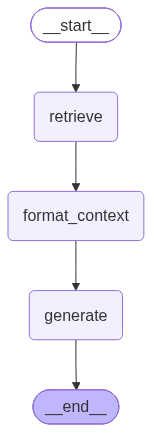

In [83]:
from IPython.display import Image, display

display(
    Image(
        rag_graph.get_graph().draw_mermaid_png()
    )
)

#### Run the LangGraph RAG

In [84]:
result = rag_graph.invoke({
    "question": "What projects has Smruti worked on?"
})

print(result["answer"])

Smruti has worked on two personal projects:

1. **Deep Packet Inspection** – a multithreaded packet‑inspection engine built in C++17 with custom parsers for Ethernet, IPv4, TCP/UDP, and TLS, plus a load‑balancer, thread‑pool pipeline, lock‑based producer‑consumer queue, and flow‑granular traffic control. [Source: resume_page1_chunk0]

2. **CascadeLog – Hybrid Log Classification System** – a three‑tier NLP/ML log‑classification pipeline (regex → sentence‑transformer embeddings with logistic regression → LLM fallback), delivered as a full‑stack FastAPI + React app, Dockerized and CI/CD‑enabled. [Source: resume_page1_chunk0]


#### Inspect the entire graph state

In [85]:
print("QUESTION:")
print(result["question"])

print("\nDOCUMENTS:")
for doc in result["documents"]:
    print(doc.metadata.get("chunk_id"))

print("\nCONTEXT:")
print(result["context"])

print("\nANSWER:")
print(result["answer"])

QUESTION:
What projects has Smruti worked on?

DOCUMENTS:
resume_page1_chunk0
resume_page1_chunk1

CONTEXT:
[Source: resume_page1_chunk0 | Page: 0 | File: c:\projects\RAG\data\pdf\resume.pdf]
Smruti Ranjan Kodamasingh♂phone+91-9178763926
Software engineer✉smrutiranjankodamasingh19@gmail.com
Bachelor of Technology /githubGitHub Profile
Kalinga Institute of Industrial Technology, Bhubaneswar/linkedinLinkedIn Profile
Educa tion
•Bachelor of Technology in Computer Science and Engineering2021-25
Kalinga Institute of Industrial Technology, BhubaneswarCGPA: 8.4
Personal Projects
•Deep Packet Inspection
C++, FastAPI, React, Docker, GitHub ActionsLive link | GitHub
–Built a multithreaded packet-inspection engine in C++17 from raw sockets up, writing custom byte-level parsers
for Ethernet, IPv4, TCP/UDP, and TLS ClientHello (SNI extraction) with zero external networking libraries.
–Architected a load-balancer→fast-path thread-pool pipeline using consistent hashing on the 5-tuple (src/dst IP,
por

#### Creating a test function

In [86]:
def test_rag(question: str):
    result = rag_graph.invoke({
        "question": question
    })

    print("=" * 100)
    print("QUESTION")
    print("=" * 100)
    print(question)

    print("\nANSWER")
    print("=" * 100)
    print(result["answer"])

    print("\nRETRIEVED CHUNKS")
    print("=" * 100)

    for doc in result["documents"]:
        print(
            doc.metadata.get("chunk_id")
        )

    print()

#### Test-1

In [87]:
test_rag(
    "What programming languages does Smruti know?"
)

QUESTION
What programming languages does Smruti know?

ANSWER
Smruti knows the following programming languages: Python, C++, Java, SQL, and JavaScript. 【Source: resume_page1_chunk0】

RETRIEVED CHUNKS
resume_page1_chunk0
resume_page1_chunk1



#### Test-2

In [88]:
test_rag(
    "What is Smruti's current job?"
)

QUESTION
What is Smruti's current job?

ANSWER
Smruti is currently working as an **Oracle EPM Implementation Consultant** at **LTIMindtree in Bengaluru** (May 2025 – Present)【Source: resume_page1_chunk0】

RETRIEVED CHUNKS
resume_page1_chunk0
resume_page1_chunk1



#### Test-3: hallucination test

In [89]:
test_rag(
    "What is Smruti's expected salary?"
)

QUESTION
What is Smruti's expected salary?

ANSWER
I don't have enough information in the provided documents.

RETRIEVED CHUNKS
resume_page1_chunk0
resume_page1_chunk1



#### Testing info not mentioned explicitly

In [90]:
test_rag(
    "How many years of professional experience does Smruti have?"
)

QUESTION
How many years of professional experience does Smruti have?

ANSWER
Smruti’s professional experience includes a 3‑month AI/ML trainee role (Dec 2023 – Feb 2024) and an Oracle EPM Implementation Consultant position that began in May 2025 and is ongoing, giving him a little over one year of full‑time experience to date【resume_page1_chunk0】【resume_page1_chunk1】.

RETRIEVED CHUNKS
resume_page1_chunk0
resume_page1_chunk1

